In [1]:
import Pkg

Pkg.add([
    "CUDA",
    "Oceananigans",
    "NumericalEarth",
    "CairoMakie",
    "JLD2"
])

   Resolving package versions...
     Project No packages added to or removed from `C:\Users\meghn\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\meghn\.julia\environments\v1.12\Manifest.toml`


In [1]:
using NumericalEarth
using Oceananigans
using Oceananigans.Units
using Oceananigans.Grids: node
using Oceananigans.TurbulenceClosures: IsopycnalSkewSymmetricDiffusivity, AdvectiveFormulation
using Dates
using Printf
using Statistics
using CUDA

In [2]:
# determining run version/params
use_rivers = false
run_days = 180

if use_rivers
        run_name = "rivers_on"
else    
        run_name = "rivers_off"
end 

# create separate filenames for each output type
surface_filename = "amazon_$(run_name)_surface_fields"
free_surface_filename = "amazon_$(run_name)_free_surface"
dye_3d_filename = "amazon_$(run_name)_dye_3d"
salinity_3d_filename = "amazon_$(run_name)_salinity_3d"

"amazon_rivers_off_salinity_3d"

In [4]:

arch = GPU()

# grid definitions -- amazon river mouth / plume region


long_west = -58.5
long_east = -41.5
lat_south = -7.8
lat_north = 9.2

Nx = 170
Ny = 170
Nz = 20

long_river = -49.5
lat_river  = 0.16

depth = 4000meters # decreased depth to 4k for this test 

z = ExponentialDiscretization(Nz, -depth, 0; scale = depth/4, mutable = false)
underlying_grid = LatitudeLongitudeGrid(
    arch;
    size = (Nx, Ny, Nz),
    halo = (5, 5, 4),
    longitude = (long_west, long_east),
    latitude = (lat_south, lat_north),
    z,
    topology = (Bounded, Bounded, Bounded)
)

bottom_height = regrid_bathymetry(underlying_grid;
                                  minimum_depth = 10,
                                  interpolation_passes = 7, # reduce num passes since we want to maintain some more specific bathymetry features in the reg. grid? 
                                  major_basins = 1) # only one major basin here -- atlantic 

grid = ImmersedBoundaryGrid(underlying_grid, GridFittedBottom(bottom_height);
                            active_cells_map=true)

[ Info: Loading cached bathymetry from C:\Users\meghn\.julia\scratchspaces\904d977b-046a-4731-8b86-9235c0d1ef02\bathymetry_cache\bathymetry_170x170_-58.5_-41.5_-7.799999999999999_9.2_bf4373b1.jld2


170×170×20 ImmersedBoundaryGrid{Float64, Bounded, Bounded, Bounded} on CUDAGPU with 5×5×4 halo:
├── immersed_boundary: GridFittedBottom(mean(z)=-1080.56, min(z)=-4000.0, max(z)=0.0)
├── underlying_grid: 170×170×20 LatitudeLongitudeGrid{Float64, Bounded, Bounded, Bounded} on CUDAGPU with 5×5×4 halo
├── longitude: Bounded  λ ∈ [-58.5, -41.5] regularly spaced with Δλ=0.1
├── latitude:  Bounded  φ ∈ [-7.8, 9.2]    regularly spaced with Δφ=0.1
└── z:         Bounded  z ∈ [-4000.0, 0.0] variably spaced with min(Δz)=16.5232, max(Δz)=738.605

In [5]:

eddy_closure = IsopycnalSkewSymmetricDiffusivity(
    κ_skew = 1e3,
    κ_symmetric = 1e3,
    skew_flux_formulation = AdvectiveFormulation()
)

vertical_mixing = NumericalEarth.Oceans.default_ocean_closure()

CATKEVerticalDiffusivity{VerticallyImplicitTimeDiscretization}
├── maximum_tracer_diffusivity: Inf
├── maximum_tke_diffusivity: Inf
├── maximum_viscosity: Inf
├── minimum_tke: 1.0e-9
├── negative_tke_time_scale: 60.0
├── minimum_convective_buoyancy_flux: 1.0e-11
├── tke_time_step: Nothing
├── mixing_length: TKEBasedVerticalDiffusivities.CATKEMixingLength
│   ├── Cˢ:   1.131
│   ├── Cᵇ:   0.01
│   ├── Cʰⁱu: 0.242
│   ├── Cʰⁱc: 0.098
│   ├── Cʰⁱe: 0.548
│   ├── Cˡᵒu: 0.361
│   ├── Cˡᵒc: 0.369
│   ├── Cˡᵒe: 7.863
│   ├── Cᵘⁿu: 0.37
│   ├── Cᵘⁿc: 0.572
│   ├── Cᵘⁿe: 1.447
│   ├── Cᶜu:  3.705
│   ├── Cᶜc:  4.793
│   ├── Cᶜe:  3.642
│   ├── Cᵉc:  0.112
│   ├── Cᵉe:  0.0
│   ├── Cˢᵖ:  0.505
│   ├── CRiᵟ: 1.02
│   └── CRi⁰: 0.254
└── turbulent_kinetic_energy_equation: TKEBasedVerticalDiffusivities.CATKEEquation
    ├── CʰⁱD: 0.579
    ├── CˡᵒD: 1.604
    ├── CᵘⁿD: 0.923
    ├── CᶜD:  3.254
    ├── CᵉD:  0.0
    ├── Cᵂu★: 3.179
    ├── CᵂwΔ: 0.383
    └── Cᵂϵ:  1.0

In [ ]:
free_surface = SplitExplicitFreeSurface(grid; substeps = 70)
momentum_advection = WENOVectorInvariant(order = 5)
tracer_advection   = WENO(order = 5)


# create zero-gradient (Neumann) boundary conditions for dye 
# "flow out" part of the model 
dye_bcs = FieldBoundaryConditions(
    west   = GradientBoundaryCondition(0),
    east   = GradientBoundaryCondition(0),
    south  = GradientBoundaryCondition(0),
    north  = GradientBoundaryCondition(0),
    top    = FluxBoundaryCondition(0),
    bottom = FluxBoundaryCondition(0)
)

# compile tracer boundary conditions for the model
model_bcs = (
    # cant use t/s as neumann boundary tracers b/c atmospheric forcing --> unstable 
    # T   = tracer_bcs, 
    # S   = tracer_bcs,
    dye = dye_bcs,
)

# updated sponge layer logic!
# summary: inital sponge was too large + errored. kept on throwing invalidIREerror. Oceanangians converts the sponge relaxation into a continuous form, which isn't compatible with the GPU, hence the error
# made a manual function creating the gaussian mask for the northern bounday, but then applied the relaxation in discrete form 

# store as gpu-accessible constant
const north_sponge_mask = GaussianMask{:y}(
    center = 9.2,
    width = 0.25
)

# store as a gpu-accessible constant
const north_sponge_rate = 1 / 5days

# apply gaussian dye relaxation in discrete form
@inline function north_dye_sponge(i, j, k, grid, clock, model_fields)
    # get the coordinates of dye cell
    x, y, z = node(i, j, k, grid, Center(), Center(), Center())

    # evaluate gaussian mask from oceaningans at this cell
    mask = north_sponge_mask(x, y, z)

    # read the local dye concentration + relax towards 0 
    dye = @inbounds model_fields.dye[i, j, k]
    return -north_sponge_rate * mask * dye

end

# use the discrete form to avoid the bug 
dye_sponge = Forcing(
    north_dye_sponge;
    discrete_form = true
)

# apply the sponge only to dye
model_forcing = (
    dye = dye_sponge,
)
                        
# added dye + boundary conditions to the model 
ocean = ocean_simulation(grid;
                         momentum_advection, tracer_advection, free_surface,
                         closure = (eddy_closure, vertical_mixing),
                         tracers = (:T, :S, :dye),
                         boundary_conditions = model_bcs,
                         forcing = model_forcing
                         )

# instead of floating dye patch, new dye patch centered on the river mouth, fading with distance
# dye is initially deposited only in the upper 10 meters
@inline function dye_initial_condition(x, y, z)
    horizontal_width = 0.5

    horizontal_blob = exp(-((x - long_river)^2 + (y - lat_river)^2) / horizontal_width^2)

    if z > -10
        return horizontal_blob
    else
        return 0
    end
end

# print the model structure so we can check that dye is listed as a tracer and that the boundary conditions were set to 0 gradient
@info "We've built an ocean simulation with model:"
@show ocean.model
@show ocean.model.tracers.dye.boundary_conditions



ocean.model = HydrostaticFreeSurfaceModel{CUDAGPU, ImmersedBoundaryGrid}(time = 0 seconds, iteration = 0)
├── grid: 170×170×20 ImmersedBoundaryGrid{Float64, Bounded, Bounded, Bounded} on CUDAGPU with 5×5×4 halo
├── timestepper: SplitRungeKuttaTimeStepper
├── tracers: (T, S, dye, e)
├── closure: Tuple with 2 closures:
│   ├── CATKEVerticalDiffusivity{VerticallyImplicitTimeDiscretization}
│   └── IsopycnalSkewSymmetricDiffusivity(κ_skew=1000.0, κ_symmetric=1000.0)
├── buoyancy: SeawaterBuoyancy with g=9.80665 and BoussinesqEquationOfState{Float64} with ĝ = NegativeZDirection()
├── free surface: SplitExplicitFreeSurface with gravitational acceleration 9.80665 m s⁻²
│   └── substepping: FixedSubstepNumber(50)
├── advection scheme: 
│   ├── momentum: WENOVectorInvariant{3, Float64}(vorticity_order=5, vertical_order=5)
│   ├── T: WENO{3, Float64, Oceananigans.Utils.BackendOptimizedDivision}(order=5)
│   ├── S: WENO{3, Float64, Oceananigans.Utils.BackendOptimizedDivision}(order=5)
│   ├── dy

[ Info: We've built an ocean simulation with model:


Oceananigans.FieldBoundaryConditions, with boundary conditions
├── west: GradientBoundaryCondition: 0.0
├── east: GradientBoundaryCondition: 0.0
├── south: GradientBoundaryCondition: 0.0
├── north: GradientBoundaryCondition: 0.0
├── bottom: FluxBoundaryCondition: 0.0
├── top: FluxBoundaryCondition: 0.0
└── immersed: FluxBoundaryCondition: Nothing


Oceananigans.FieldBoundaryConditions, with boundary conditions
├── west: GradientBoundaryCondition: 0.0
├── east: GradientBoundaryCondition: 0.0
├── south: GradientBoundaryCondition: 0.0
├── north: GradientBoundaryCondition: 0.0
├── bottom: FluxBoundaryCondition: 0.0
├── top: FluxBoundaryCondition: 0.0
└── immersed: FluxBoundaryCondition: Nothing

In [ ]:
# ask for ecco credentials at runtime so they are not saved in the notebook
println("Enter ECCO username:")
ENV["ECCO_USERNAME"] = readline()


println("Enter ECCO password:")
ENV["ECCO_PASSWORD"] = readline()


date = DateTime(1993, 1, 1)

ecco_variables = (:temperature, :salinity)
ecco_set = MetadataSet(ecco_variables; dataset = ECCO4Monthly(), date)

# we aren't initializing the tracer just yet (first spinning-up the model for a year)
set!(ocean.model,   ecco_set)  

# print out all of the tracers 
@show keys(ocean.model.tracers)

keys(ocean.model.tracers) = (:T, :S, :dye, :e)


(:T, :S, :dye, :e)

In [8]:

land = JRA55PrescribedLand(arch)
atmosphere = JRA55PrescribedAtmosphere(arch)
ocean_surface = SurfaceRadiationProperties(albedo = LatitudeDependentAlbedo())
radiation = JRA55PrescribedRadiation(arch; ocean_surface)

640×320×1×2920 PrescribedRadiation on LatitudeLongitudeGrid:
├── times: 2920-element StepRangeLen{Float64, Base.TwicePrecision{Float64}, Base.TwicePrecision{Float64}, Int64}
├── stefan_boltzmann_constant: 5.67037e-8
└── surface_properties: (:ocean, :sea_ice)

In [9]:
# determining to use land in the model or not 
if use_rivers
    land_component = land
else
    land_component = nothing
end

# model with no sea ice 
coupled_model = EarthSystemModel(; ocean, atmosphere, land = land_component, radiation)

# first run for 365 days without the dye 
spinup_time = 365days

# model runs with a timestep of 20 minutes
simulation = Simulation(coupled_model;
                        Δt = 20minutes,
                        stop_time = spinup_time)

Simulation of EarthSystemModel{GPU}(time = 0 seconds, iteration = 0)
├── Next time step: 20 minutes
├── run_wall_time: 0 seconds
├── run_wall_time / iteration: NaN days
├── stop_time: 365 days
├── stop_iteration: Inf
├── wall_time_limit: Inf
├── minimum_relative_step: 0.0
├── callbacks: OrderedDict with 4 entries:
│   ├── stop_time_exceeded => Callback of stop_time_exceeded on IterationInterval(1)
│   ├── stop_iteration_exceeded => Callback of stop_iteration_exceeded on IterationInterval(1)
│   ├── wall_time_limit_exceeded => Callback of wall_time_limit_exceeded on IterationInterval(1)
│   └── nan_checker => Callback of NaNChecker for T_ocean on IterationInterval(100)
└── output_writers: OrderedDict with no entries

In [10]:

wall_time = Ref(time_ns())

function progress(sim)
 
    ocean = sim.model.ocean

    u, v, w = ocean.model.velocities

    T = ocean.model.tracers.T
    e = ocean.model.tracers.e

    # grab the dye tracer so it gets saved with the ocean output
    dye = ocean.model.tracers.dye

    Tmin, Tmax, Tavg = minimum(T), maximum(T), mean(view(T, :, :, ocean.model.grid.Nz))
    emax = maximum(e)

    # compute max speed components, so we can see if the model is behaving weirdly
    umax = (maximum(abs, u), maximum(abs, v), maximum(abs, w))

    step_time = 1e-9 * (time_ns() - wall_time[])

    msg1 = @sprintf("time: %s, iter: %d", prettytime(sim), iteration(sim))
    msg2 = @sprintf(", max|uo|: (%.1e, %.1e, %.1e) m s⁻¹", umax...)
    msg3 = @sprintf(", extrema(To): (%.1f, %.1f) ᵒC, mean(To(z=0)): %.1f ᵒC", Tmin, Tmax, Tavg)
    msg4 = @sprintf(", max(e): %.2f m² s⁻²", emax)
    msg5 = @sprintf(", wall time: %s \n", prettytime(step_time))

    @info msg1 * msg2 * msg3 * msg4 * msg5

    wall_time[] = time_ns()

     return nothing
end

progress (generic function with 1 method)

In [11]:

add_callback!(simulation, progress, TimeInterval(5days))

In [12]:
# run the spinup simulation first
run!(simulation)

# save the exact time when the spinup ended 
dye_release_time = time(simulation)

@info "Spin up finisehd at $(prettytime(dye_release_time))"

[ Info: Initializing simulation...
[ Info: time: 0 seconds, iter: 0, max|uo|: (0.0e+00, 0.0e+00, 0.0e+00) m s⁻¹, extrema(To): (2.1, 28.2) ᵒC, mean(To(z=0)): 27.0 ᵒC, max(e): 0.00 m² s⁻², wall time: 30.994 seconds 
[ Info:     ... simulation initialization complete (23.368 seconds)
[ Info: Executing initial time step...
[ Info:     ... initial time step complete (2.431 minutes).
[ Info: time: 5 days, iter: 360, max|uo|: (7.7e-01, 5.6e-01, 1.3e-03) m s⁻¹, extrema(To): (2.1, 29.0) ᵒC, mean(To(z=0)): 27.1 ᵒC, max(e): 0.00 m² s⁻², wall time: 3.978 minutes 
[ Info: time: 10 days, iter: 720, max|uo|: (8.9e-01, 5.1e-01, 2.4e-03) m s⁻¹, extrema(To): (2.1, 29.6) ᵒC, mean(To(z=0)): 27.1 ᵒC, max(e): 0.00 m² s⁻², wall time: 1.622 minutes 
[ Info: time: 15 days, iter: 1080, max|uo|: (8.2e-01, 5.0e-01, 1.8e-03) m s⁻¹, extrema(To): (2.1, 30.1) ᵒC, mean(To(z=0)): 27.0 ᵒC, max(e): 0.00 m² s⁻², wall time: 1.628 minutes 
[ Info: time: 20 days, iter: 1440, max|uo|: (6.5e-01, 8.3e-01, 1.8e-03) m s⁻¹, extrem

In [13]:
# collect the surface tracers + velocities
ocean_outputs = merge(ocean.model.tracers, ocean.model.velocities)

# collect full 3d salinity + dye for transects 
dye_output = (
    dye = ocean.model.tracers.dye,
)
salinity_output = (
    S = ocean.model.tracers.S,
)

# grab the free-surface displacement
free_surface = ocean.model.free_surface.displacement

# save daily surface tracers + velocities
ocean.output_writers[:surface] = JLD2Writer(
    ocean.model,
    ocean_outputs;
    schedule = TimeInterval(1days),
    filename = surface_filename,
    indices = (:, :, grid.Nz),
    overwrite_existing = true
)

# save daily sea-surface height to a separate file
ocean.output_writers[:free_surface] = JLD2Writer(
    ocean.model,
    (; η = free_surface);
    schedule = TimeInterval(1days),
    filename = free_surface_filename,
    overwrite_existing = true
)

# save full 3d dye daily for transects + tracer amount calculations
ocean.output_writers[:dye_3d] = JLD2Writer(
    ocean.model,
    dye_output;
    schedule = TimeInterval(1days),
    filename = dye_3d_filename,
    overwrite_existing = true
)

# save full 3d salinity every 5 days for freshwater-plume transects
ocean.output_writers[:salinity_3d] = JLD2Writer(
    ocean.model,
    salinity_output;
    schedule = TimeInterval(5days),
    filename = salinity_3d_filename,
    overwrite_existing = true
)

JLD2Writer scheduled on TimeInterval(5 days):
├── filepath: amazon_rivers_off_salinity_3d.jld2
├── 1 outputs: S
├── array_type: Array{Float32}
├── including: [:coriolis, :buoyancy, :closure]
├── file_splitting: NoFileSplitting
└── file size: 0 bytes (file not yet created)

In [14]:
# set the ocean model to include the dye deposit after spinup
set!(ocean.model, dye = dye_initial_condition)

simulation.stop_time = dye_release_time + run_days*days

# run post-spin-up tracer 
run!(simulation)

[ Info: Initializing simulation...
[ Info:     ... simulation initialization complete (666 μs)
[ Info: Executing initial time step...
[ Info:     ... initial time step complete (16.879 seconds).
[ Info: time: 370 days, iter: 26640, max|uo|: (9.9e-01, 6.9e-01, 1.3e-03) m s⁻¹, extrema(To): (2.1, 33.2) ᵒC, mean(To(z=0)): 28.0 ᵒC, max(e): 0.00 m² s⁻², wall time: 1.990 minutes 
[ Info: time: 375 days, iter: 27000, max|uo|: (9.3e-01, 6.2e-01, 2.5e-03) m s⁻¹, extrema(To): (2.1, 32.8) ᵒC, mean(To(z=0)): 27.9 ᵒC, max(e): 0.00 m² s⁻², wall time: 1.460 minutes 
[ Info: time: 380 days, iter: 27360, max|uo|: (9.6e-01, 6.2e-01, 1.7e-03) m s⁻¹, extrema(To): (2.1, 32.7) ᵒC, mean(To(z=0)): 27.7 ᵒC, max(e): 0.00 m² s⁻², wall time: 1.465 minutes 
[ Info: time: 385 days, iter: 27720, max|uo|: (7.6e-01, 6.0e-01, 1.5e-03) m s⁻¹, extrema(To): (2.1, 32.1) ᵒC, mean(To(z=0)): 27.6 ᵒC, max(e): 0.00 m² s⁻², wall time: 1.487 minutes 
[ Info: time: 390 days, iter: 28080, max|uo|: (7.3e-01, 5.5e-01, 1.4e-03) m s⁻¹, 

In [3]:

# add the file extension used by fieldtimeseries
surface_filepath = surface_filename * ".jld2"
free_surface_filepath = free_surface_filename * ".jld2"
dye_3d_filepath = dye_3d_filename * ".jld2"
salinity_3d_filepath = salinity_3d_filename * ".jld2"

# load daily surface fields
uo = FieldTimeSeries(surface_filepath, "u"; backend = OnDisk())
vo = FieldTimeSeries(surface_filepath, "v"; backend = OnDisk())
To = FieldTimeSeries(surface_filepath, "T"; backend = OnDisk())
So = FieldTimeSeries(surface_filepath, "S"; backend = OnDisk())
eo = FieldTimeSeries(surface_filepath, "e"; backend = OnDisk())
dye = FieldTimeSeries(surface_filepath, "dye"; backend = OnDisk())
ηo = FieldTimeSeries(free_surface_filepath, "η"; backend = OnDisk())

# load full 3d dye saved daily
dye_3d = FieldTimeSeries(dye_3d_filepath, "dye"; backend = OnDisk())
# load full 3d salinity saved every 5 days
S_3d = FieldTimeSeries(salinity_3d_filepath, "S"; backend = OnDisk())

# check the output times + dimensions
@show length(So.times)
@show So.times ./ days
@show length(dye_3d.times)
@show dye_3d.times ./ days
@show length(S_3d.times)
@show S_3d.times ./ days
@show size(interior(dye_3d[1]))
@show size(interior(S_3d[1]))

length(So.times) = 181
So.times ./ days = [365.0138888888889, 366.0, 367.0, 368.0, 369.0, 370.0, 371.0, 372.0, 373.0, 374.0, 375.0, 376.0, 377.0, 378.0, 379.0, 380.0, 381.0, 382.0, 383.0, 384.0, 385.0, 386.0, 387.0, 388.0, 389.0, 390.0, 391.0, 392.0, 393.0, 394.0, 395.0, 396.0, 397.0, 398.0, 399.0, 400.0, 401.0, 402.0, 403.0, 404.0, 405.0, 406.0, 407.0, 408.0, 409.0, 410.0, 411.0, 412.0, 413.0, 414.0, 415.0, 416.0, 417.0, 418.0, 419.0, 420.0, 421.0, 422.0, 423.0, 424.0, 425.0, 426.0, 427.0, 428.0, 429.0, 430.0, 431.0, 432.0, 433.0, 434.0, 435.0, 436.0, 437.0, 438.0, 439.0, 440.0, 441.0, 442.0, 443.0, 444.0, 445.0, 446.0, 447.0, 448.0, 449.0, 450.0, 451.0, 452.0, 453.0, 454.0, 455.0, 456.0, 457.0, 458.0, 459.0, 460.0, 461.0, 462.0, 463.0, 464.0, 465.0, 466.0, 467.0, 468.0, 469.0, 470.0, 471.0, 472.0, 473.0, 474.0, 475.0, 476.0, 477.0, 478.0, 479.0, 480.0, 481.0, 482.0, 483.0, 484.0, 485.0, 486.0, 487.0, 488.0, 489.0, 490.0, 491.0, 492.0, 493.0, 494.0, 495.0, 496.0, 497.0, 498.0, 499.0, 

(170, 170, 20)

In [4]:

using CairoMakie

times = To.times
Nt = minimum((length(uo.times), length(vo.times), length(To.times), length(So.times), length(eo.times), length(dye.times), length(ηo.times)))
n = Observable(1)

Observable(1)


In [13]:
# land mask from bathymetry
land_full = interior(To.grid.immersed_boundary.bottom_height) .≥ 0

Toₙ = @lift begin
    Tₙ = Array(interior(To[$n]))

    land = falses(size(Tₙ))
    i = min(size(Tₙ, 1), size(land_full, 1))
    j = min(size(Tₙ, 2), size(land_full, 2))
    k = min(size(Tₙ, 3), size(land_full, 3))
    land[1:i, 1:j, 1:k] .= land_full[1:i, 1:j, 1:k]

    Tₙ[land] .= NaN
    view(Tₙ, :, :, 1)
end

eoₙ = @lift begin
    eₙ = Array(interior(eo[$n]))

    land = falses(size(eₙ))
    i = min(size(eₙ, 1), size(land_full, 1))
    j = min(size(eₙ, 2), size(land_full, 2))
    k = min(size(eₙ, 3), size(land_full, 3))
    land[1:i, 1:j, 1:k] .= land_full[1:i, 1:j, 1:k]

    eₙ[land] .= NaN
    view(eₙ, :, :, 1)
end

ηoₙ = @lift begin
    ηₙ = Array(interior(ηo[$n]))

    land = falses(size(ηₙ))
    i = min(size(ηₙ, 1), size(land_full, 1))
    j = min(size(ηₙ, 2), size(land_full, 2))
    k = min(size(ηₙ, 3), size(land_full, 3))
    land[1:i, 1:j, 1:k] .= land_full[1:i, 1:j, 1:k]

    ηₙ[land] .= NaN
    view(ηₙ, :, :, 1)
end

uoₙ = Field{Face, Center, Nothing}(uo.grid)
voₙ = Field{Center, Face, Nothing}(vo.grid)
so = Field(sqrt(uoₙ^2 + voₙ^2))

soₙ = @lift begin
    parent(uoₙ) .= parent(uo[$n])
    parent(voₙ) .= parent(vo[$n])
    compute!(so)

    sₙ = Array(interior(so))

    land = falses(size(sₙ))
    i = min(size(sₙ, 1), size(land_full, 1))
    j = min(size(sₙ, 2), size(land_full, 2))
    k = min(size(sₙ, 3), size(land_full, 3))
    land[1:i, 1:j, 1:k] .= land_full[1:i, 1:j, 1:k]

    sₙ[land] .= NaN
    view(sₙ, :, :, 1)
end

dyeₙ = @lift begin
    d = Array(interior(dye[$n]))

    land = falses(size(d))
    i = min(size(d, 1), size(land_full, 1))
    j = min(size(d, 2), size(land_full, 2))
    k = min(size(d, 3), size(land_full, 3))
    land[1:i, 1:j, 1:k] .= land_full[1:i, 1:j, 1:k]

    d[land] .= NaN
    d_log = log10.(max.(d, 0) .+ 1e-16)

    view(d_log, :, :, 1)
end

Soₙ = @lift begin
    Sₙ = Array(interior(So[$n]))

    land = falses(size(Sₙ))
    i = min(size(Sₙ, 1), size(land_full, 1))
    j = min(size(Sₙ, 2), size(land_full, 2))
    k = min(size(Sₙ, 3), size(land_full, 3))
    land[1:i, 1:j, 1:k] .= land_full[1:i, 1:j, 1:k]

    Sₙ[land] .= NaN
    view(Sₙ, :, :, 1)
end

Observable(Float32[NaN NaN … 34.870396 34.862633; NaN NaN … 34.90253 34.866528; … ; NaN NaN … 35.854485 35.87576; NaN NaN … 35.89213 35.90831])


In [14]:
fig = Figure(size = (1200, 1600))

title = @lift string("amazon river snapshot ", prettytime(times[$n] - times[1]))

axso = Axis(fig[1, 1])
axηo = Axis(fig[1, 3])
axTo = Axis(fig[2, 1])
axeo = Axis(fig[2, 3])
axdye = Axis(fig[3, 1])
axSo = Axis(fig[3, 3])

hm = heatmap!(axso, soₙ, colorrange = (0, 0.25), colormap = :deep, nan_color = :lightgray)
Colorbar(fig[1, 2], hm, label = "Ocean Surface Speed (m s⁻¹)")

hm = heatmap!(axηo, ηoₙ, colorrange = (-.1, .5), colormap = :balance, nan_color = :lightgray)
Colorbar(fig[1, 4], hm, label = "Sea Surface Height (m)")

hm = heatmap!(axTo, Toₙ, colorrange = (26, 32), colormap = :magma, nan_color = :lightgray)
Colorbar(fig[2, 2], hm, label = "Surface Temperature (ᵒC)")

hm = heatmap!(axeo, eoₙ, colorrange = (0, 3e-4), colormap = :solar, nan_color = :lightgray)
Colorbar(fig[2, 4], hm, label = "Turbulent Kinetic Energy (m² s⁻²)")

hm = heatmap!(axdye, dyeₙ, colorrange = (-8, 0), colormap = :viridis, nan_color = :lightgray)
Colorbar(fig[3, 2], hm, label = "log₁₀(passive dye + 1e-16)")

hm = heatmap!(axSo, Soₙ, colorrange = (32, 37), colormap = :haline, nan_color = :lightgray)
Colorbar(fig[3, 4], hm, label = "Surface Salinity (g kg^-1)")

for ax in (axso, axηo, axTo, axeo, axdye, axSo)
    hidedecorations!(ax)
end

Label(fig[0, :], title)


# update img to be the last saved timestep
n[] = Nt

save("amazon_salinity_$(run_name)_snapshot.png", fig)

LoadError: BoundsError: attempt to access 37-element Vector{Float64} at index [181]

In [7]:
CairoMakie.record(fig, "amazon_salinity_$(run_name).mp4", 1:Nt; framerate = 8) do nn
    n[] = nn
end

"amazon_salinity_rivers_off.mp4"

rivers-on snapshots: 37
rivers-off snapshots: 37
frames being compared: 37
saved days: [360.0138888888889, 365.0, 370.0, 375.0, 380.0, 385.0, 390.0, 395.0, 400.0, 405.0, 410.0, 415.0, 420.0, 425.0, 430.0, 435.0, 440.0, 445.0, 450.0, 455.0, 460.0, 465.0, 470.0, 475.0, 480.0, 485.0, 490.0, 495.0, 500.0, 505.0, 510.0, 515.0, 520.0, 525.0, 530.0, 535.0, 540.0]
surface layer: 20


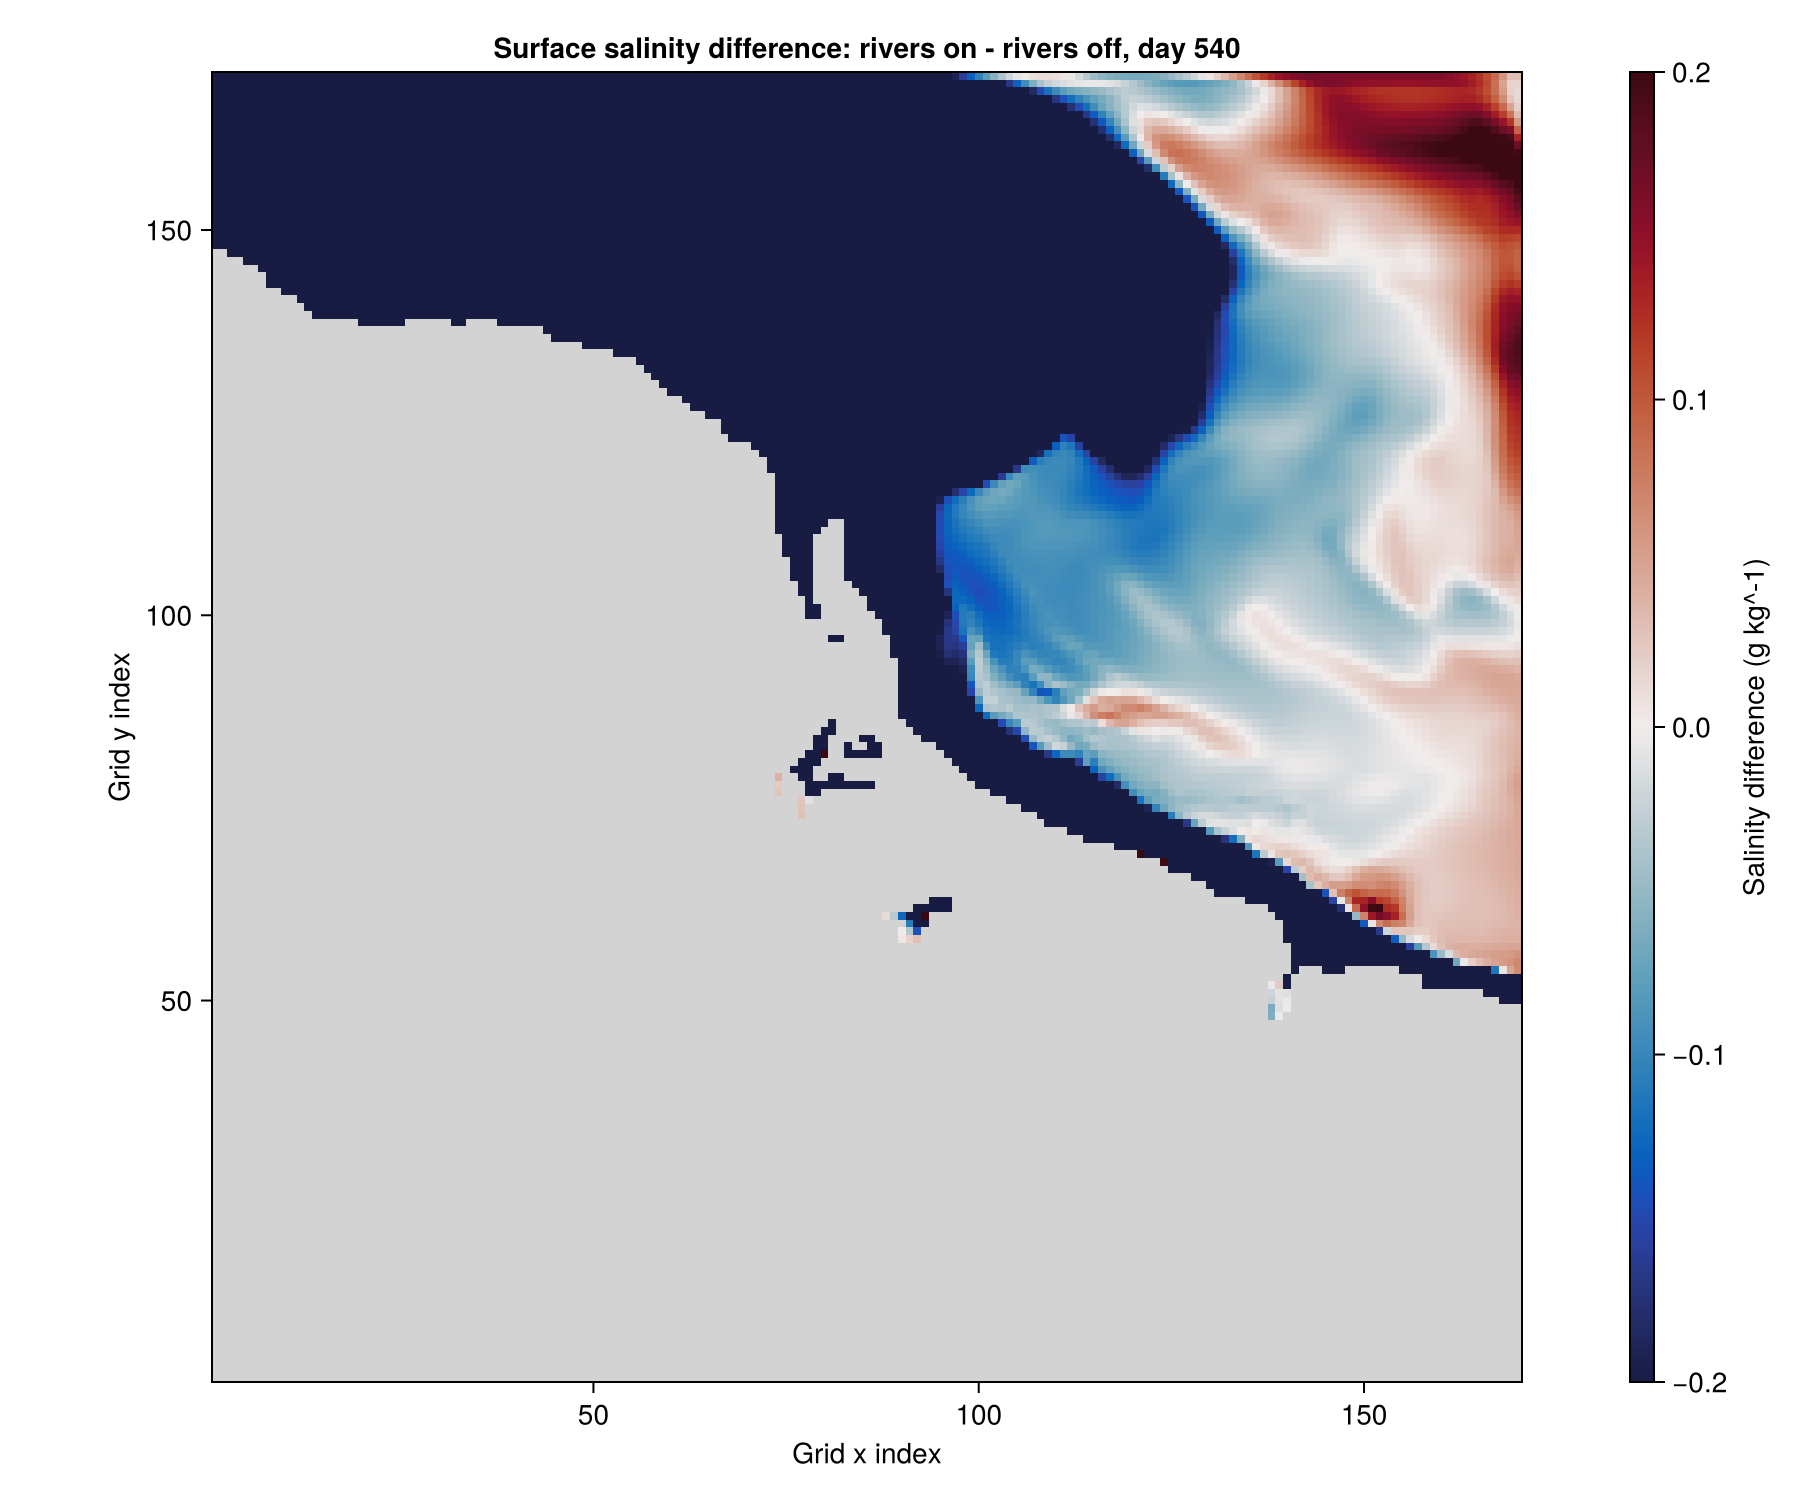

In [15]:
using CairoMakie
using Oceananigans
using Oceananigans.Units
using Observables

# load full 3d salinity from both simulations
S_on = FieldTimeSeries(
    "amazon_rivers_on_salinity_3d.jld2",
    "S";
    backend = OnDisk()
)

S_off = FieldTimeSeries(
    "amazon_rivers_off_salinity_3d.jld2",
    "S";
    backend = OnDisk()
)

# use only snapshots available in both simulations
Nt = min(length(S_on.times), length(S_off.times))
times = S_on.times[1:Nt]
frame = Observable(1)

# identify the uppermost vertical grid cell
top_layer = size(interior(S_on[1]), 3)

println("rivers-on snapshots: ", length(S_on.times))
println("rivers-off snapshots: ", length(S_off.times))
println("frames being compared: ", Nt)
println("saved days: ", times ./ days)
println("surface layer: ", top_layer)

# calculate rivers-on minus rivers-off surface salinity
salinity_difference = @lift begin
    salinity_on = Array(
        interior(S_on[$frame], :, :, top_layer)
    )

    salinity_off = Array(
        interior(S_off[$frame], :, :, top_layer)
    )

    difference = fill(NaN, size(salinity_on))

    for j in axes(difference, 2)
        for i in axes(difference, 1)
            on_value = salinity_on[i, j]
            off_value = salinity_off[i, j]

            values_are_valid =
                isfinite(on_value) &&
                isfinite(off_value) &&
                on_value > 20 &&
                on_value < 40 &&
                off_value > 20 &&
                off_value < 40

            if values_are_valid
                difference[i, j] = on_value - off_value
            end
        end
    end

    difference
end

# update the title with the current saved day
title = @lift string(
    "Surface salinity difference: rivers on - rivers off, day ",
    round(Int, times[$frame] / days)
)

# create the surface salinity-difference plot
figure = Figure(size = (900, 750))

axis = Axis(
    figure[1, 1],
    title = title,
    xlabel = "Grid x index",
    ylabel = "Grid y index",
    aspect = DataAspect()
)

heatmap_plot = heatmap!(
    axis,
    salinity_difference;
    colorrange = (-0.2, 0.2),
    colormap = :balance,
    nan_color = :lightgray
)

Colorbar(
    figure[1, 2],
    heatmap_plot;
    label = "Salinity difference (g kg^-1)"
)

# save the final shared snapshot
frame[] = Nt

save(
    "amazon_salinity_difference_snapshot.png",
    figure
)

# animate all shared salinity snapshots
CairoMakie.record(
    figure,
    "amazon_salinity_difference.mp4",
    1:Nt;
    framerate = 4
) do current_frame
    frame[] = current_frame
end

figure